# Homework 4 
# ESG Fundamentals and Equity-Market Depth

### A reproducible cross-country sustainable-investing study
 
**Period:** 2018–2022 medium-run averages  
**Unit of analysis:** Country / equity market  
**Data:** World Development Indicators (WDI) and Worldwide Governance Indicators (WGI), downloaded only through official World Bank APIs

> **Main finding** A broad ESG composite is not statistically significant after macroeconomic controls, but the governance pillar has a large, positive, and robust association with stock-market capitalization relative to GDP. The distinction matters: an aggregate ESG score can conceal the pillar that carries the investable signal.

---

## A. Motivation, policy relevance, and research questions

### Personal motivation

I study sustainable development, so I want to connect sustainability outcomes to the way capital markets allocate and price capital. I am also preparing for the CFA Institute Sustainable Investing Certificate, which was formerly named the Certificate in ESG Investing. CFA Institute explains that the renamed certificate retains coverage of environmental, social, and governance factors and their integration into investment decisions ([official program page](https://www.cfainstitute.org/programs/esg-certification)). This project lets me apply that framework empirically rather than treating ESG as a purely qualitative label.

### Research questions

1. **Composite question:** Across countries, are stronger ESG fundamentals associated with deeper domestic equity markets after controlling for income, trade openness, and population?
2. **Pillar question:** When E, S, and G are modeled separately, which pillar has the clearest conditional association with equity-market depth?

### Hypotheses and relevance

- **H1:** Higher composite ESG fundamentals are associated with higher stock-market capitalization as a share of GDP.
- **H2:** Governance has the strongest adjusted association because rule of law, regulatory quality, and corruption control can reduce agency, enforcement, and institutional risks faced by investors.
- **Policy / investment relevance:** Market development can broaden access to long-term transition finance, while investors need to know whether a headline ESG score hides materially different environmental, social, and governance exposures.

This is an **observational association study**, not a causal test and not an investment recommendation.

## B. Research design

To reduce one-year noise, each country is represented by its **2018–2022 average**. The dependent variable is stock-market capitalization as a percentage of GDP. Because this ratio is right-skewed, the analysis winsorizes it at the 2nd and 98th percentiles and models `log(1 + market_cap_gdp)`.

The country ESG measure is a transparent research proxy—not a commercial issuer rating. Each input is converted to a within-sample percentile (0–100), oriented so that a higher number is interpreted as stronger. Inputs receive equal weights within pillars, and E/S/G receive equal weights in the composite.

| Construct | API variables | Direction used in score |
|---|---|---|
| **Environment** | Renewable energy share (`EG.FEC.RNEW.ZS`); CO₂ intensity of PPP GDP (`EN.GHG.CO2.RT.GDP.PP.KD`) | More renewables; lower carbon intensity |
| **Social** | Life expectancy (`SP.DYN.LE00.IN`); absolute male–female labor-force participation gap (`SL.TLF.CACT.MA.ZS`, `SL.TLF.CACT.FE.ZS`) | Longer lives; smaller gender gap |
| **Governance** | WGI rule of law, regulatory quality, and control of corruption (`GOV_WGI_*.SC`) | Higher 0–100 WGI scores |
| **Equity-market outcome** | Market capitalization / GDP and current US$ (`CM.MKT.LCAP.GD.ZS`, `CM.MKT.LCAP.CD`) | Descriptive / dependent variable |
| **Controls** | PPP GDP per capita, trade / GDP, population | Log GDP per capita; standardized trade; log population |

**Source notes.** WDI is the World Bank's primary collection of development indicators ([Indicators API documentation](https://datahelpdesk.worldbank.org/knowledgebase/articles/889392)). The WGI 2025 revision recalculated historical governance estimates and provides annual indicators for more than 200 economies ([WGI documentation](https://www.worldbank.org/en/publication/worldwide-governance-indicators/documentation)). Every exact API URL is retained in the downloaded data.

## 1. Setup

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

# This works whether Jupyter starts in the repository root or notebook folder.
here = Path.cwd().resolve()
repo_root = next(
    (
        candidate
        for candidate in [here, *here.parents]
        if (candidate / "src" / "final_project" / "huang-shuo" / "basic").exists()
    ),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Could not locate the repository root from the current directory.")

project_dir = repo_root / "src" / "final_project" / "huang-shuo" / "basic"
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

import data
import graph
import manipulate
import model

print(f"Repository root: {repo_root}")
print(f"Analysis modules: {project_dir}")

Repository root: C:\Users\huang\Documents\GitHub\datascience-publicpolicy-2026#
Analysis modules: C:\Users\huang\Documents\GitHub\datascience-publicpolicy-2026#\src\final_project\huang-shuo\basic


## 2. Download data from official APIs

`data.py` makes a live API request for every series; no observation is typed by hand. Raw long-format data are saved to `data/final_project/huang-shuo/world_bank_esg_raw.csv`, including the indicator code, source database, and exact request URL.

In [2]:
df_raw = data.run(force_refresh=True)
audit = data.download_audit(df_raw)

display(audit)
print(f"Downloaded {len(df_raw):,} country-year-indicator rows.")
print(f"Raw file: {data.RAW_PATH.relative_to(repo_root)}")
print(f"Distinct API endpoints: {df_raw['api_url'].nunique()}")

,source_database,indicator,indicator_code,observations,countries,first_year,last_year
0,WDI,co2_intensity,EN.GHG.CO2.RT.GDP.PP.KD,955,191,2018,2022
1,WDI,female_lfp,SL.TLF.CACT.FE.ZS,934,187,2018,2022
2,WDI,gdp_per_capita_ppp,NY.GDP.PCAP.PP.KD,995,199,2018,2022
3,WDI,life_expectancy,SP.DYN.LE00.IN,1085,217,2018,2022
4,WDI,male_lfp,SL.TLF.CACT.MA.ZS,934,187,2018,2022
5,WDI,market_cap_gdp,CM.MKT.LCAP.GD.ZS,379,86,2018,2022
6,WDI,market_cap_usd,CM.MKT.LCAP.CD,379,86,2018,2022
7,WDI,population,SP.POP.TOTL,1085,217,2018,2022
8,WDI,renewable_share,EG.FEC.RNEW.ZS,919,212,2018,2022
9,WDI,trade_openness,NE.TRD.GNFS.ZS,918,186,2018,2022


Downloaded 13,955 country-year-indicator rows.
Raw file: data\final_project\huang-shuo\world_bank_esg_raw.csv
Distinct API endpoints: 13


**Download interpretation.** The audit confirms broad coverage for the sustainability and governance inputs, while equity-market capitalization is the binding data constraint. The WGI series use the current `GOV_WGI_*.SC` codes from source 3; this avoids the empty results produced by legacy pre-revision codes.

## 3. Manipulate, screen, and score the data

The cleaning rules are fixed before examining OLS coefficients:

1. Remove World Bank aggregates and keep actual economies.
2. Require at least three annual observations for every ESG input and macro control.
3. Require at least two annual observations for market capitalization / GDP.
4. Keep complete cases with population of at least one million and positive market depth.
5. Average 2018–2022 values, construct percentile scores, and save the processed cross-section.

In [3]:
df_clean = manipulate.run(df_raw)
sample_flow = pd.DataFrame(df_clean.attrs["sample_flow"])
display(sample_flow)

preview_columns = [
    "country", "income_group", "e_score", "s_score", "g_score",
    "esg_score", "market_cap_gdp", "esg_rank"
]
display(df_clean[preview_columns].head(10).round(2))
print(f"Processed file: {manipulate.PROCESSED_PATH.relative_to(repo_root)}")

,screen,countries
0,API economies after removing aggregates,217
1,At least 3 years for ESG inputs and controls,160
2,At least 2 years for equity-market depth,72
3,"Complete cases, population >= 1m, positive mar...",70


indicator,country,income_group,e_score,s_score,g_score,esg_score,market_cap_gdp,esg_rank
0,Norway,High income,89.290,94.290,96.190,93.250,64.240,1
1,Switzerland,High income,84.290,88.570,97.620,90.160,239.700,2
2,New Zealand,High income,67.860,86.430,98.100,84.130,48.160,3
3,Austria,High income,80.000,80.710,90.000,83.570,29.230,4
4,United Kingdom,High income,62.140,82.860,90.480,78.490,108.130,5
5,Germany,High income,60.710,76.430,92.380,76.510,51.330,6
6,Spain,High income,65.710,85.000,76.670,75.790,53.050,7
7,"Hong Kong SAR, China",High income,50.710,85.000,90.480,75.400,"1,385.710",8
8,Singapore,High income,51.430,77.860,95.240,74.840,164.700,9
9,Canada,High income,42.140,87.140,90.950,73.410,139.760,10


Processed file: data\final_project\huang-shuo\esg_investing_cross_section.csv


**Sample interpretation.** The pipeline begins with 217 non-aggregate economies. ESG/control coverage reduces this to 160, equity-market availability to 72, and the pre-specified population/complete-case screen to a final **70-country sample**. This attrition is important: conclusions apply to countries with observable formal equity markets, not to every economy.

In [4]:
summary_variables = {
    "market_cap_gdp": "Market cap / GDP (%)",
    "esg_score": "Composite ESG score",
    "e_score": "Environmental score",
    "s_score": "Social score",
    "g_score": "Governance score",
    "gdp_per_capita_ppp": "GDP per capita (PPP)",
    "trade_openness": "Trade / GDP (%)",
}
descriptive_table = (
    df_clean[list(summary_variables)]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
    .rename(index=summary_variables)
)
display(descriptive_table.style.format("{:,.2f}"))

,count,mean,std,min,25%,50%,75%,max
indicator,,,,,,,,
Market cap / GDP (%),70.00,78.70,170.60,0.50,18.65,36.12,86.91,"1,385.71"
Composite ESG score,70.00,50.71,18.52,12.22,35.95,51.35,63.81,93.25
Environmental score,70.00,50.71,26.31,3.57,30.62,50.00,72.68,99.29
Social score,70.00,50.71,21.70,7.14,34.29,47.50,66.96,94.29
Governance score,70.00,50.71,28.35,2.38,27.38,49.52,75.12,98.10
GDP per capita (PPP),70.00,"33,626.84","25,683.49","2,741.69","13,983.39","29,040.75","46,847.70","125,369.93"
Trade / GDP (%),70.00,86.68,59.91,25.80,48.73,72.45,102.68,373.73


## 4. Visualize ESG structure and market depth

### Figure 1-Pillar landscape

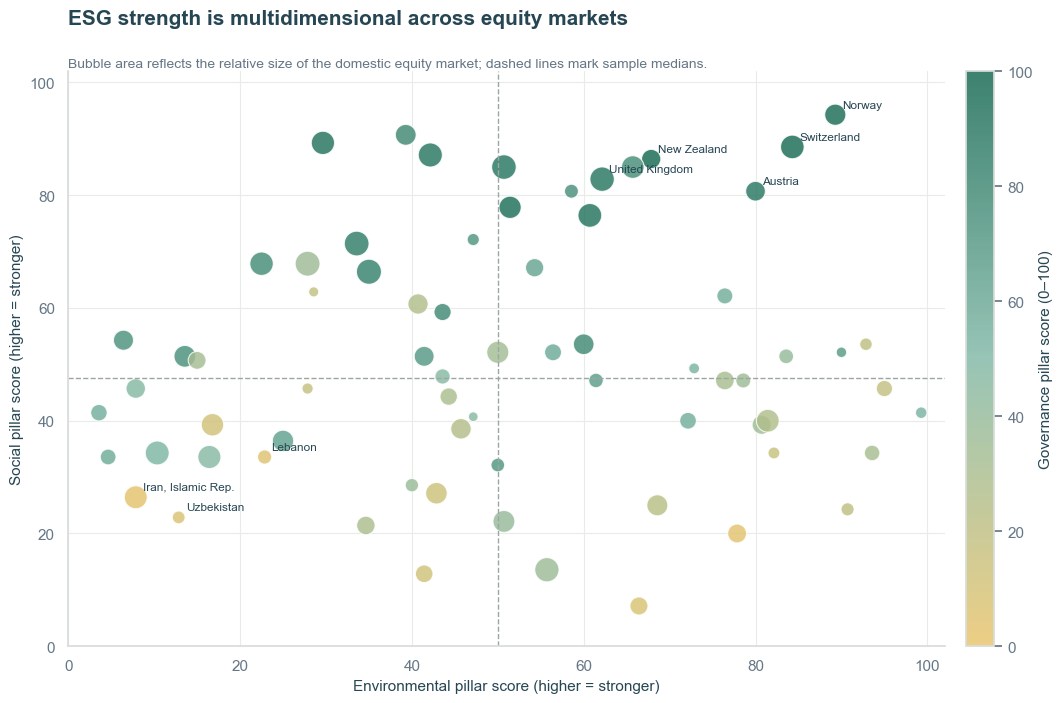

In [5]:
figure_1 = graph.plot_pillar_landscape(df_clean)
plt.show()

**Interpretation.** ESG leadership is not one-dimensional. Norway and Switzerland sit high on E, S, and G, whereas countries can be environmentally strong without equally strong social or governance scores, and vice versa. Bubble sizes also show that several of the largest markets occupy the middle rather than the top of the environmental distribution. This supports pillar-by-pillar due diligence instead of relying only on a composite rank.

### Figure 2-Composite ESG and equity-market depth

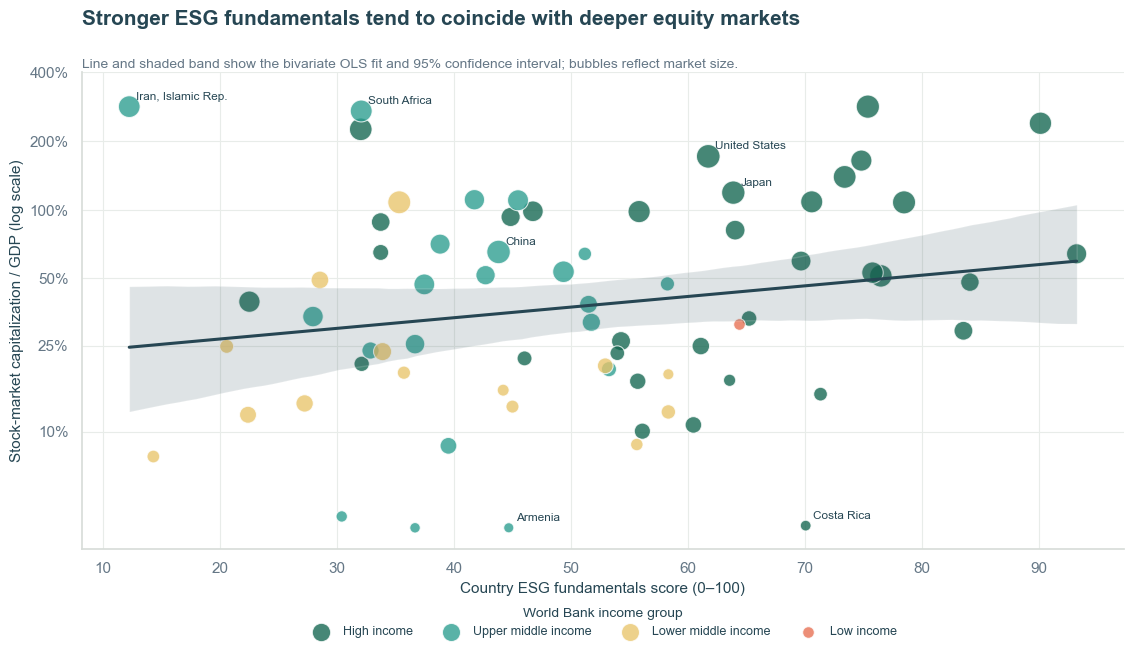

In [6]:
figure_2 = graph.plot_market_relationship(df_clean)
plt.show()

**Interpretation.** The unconditional slope is positive but imprecise: the Pearson correlation between composite ESG and log market depth is only **0.188**, and the wide confidence band reflects substantial cross-country heterogeneity. Income groups cluster differently, while markets such as South Africa and Iran sit well above the bivariate line. The plot motivates macro controls and influence diagnostics rather than a causal reading of the raw trend.

### Figure 3-ESG profiles in the largest equity markets

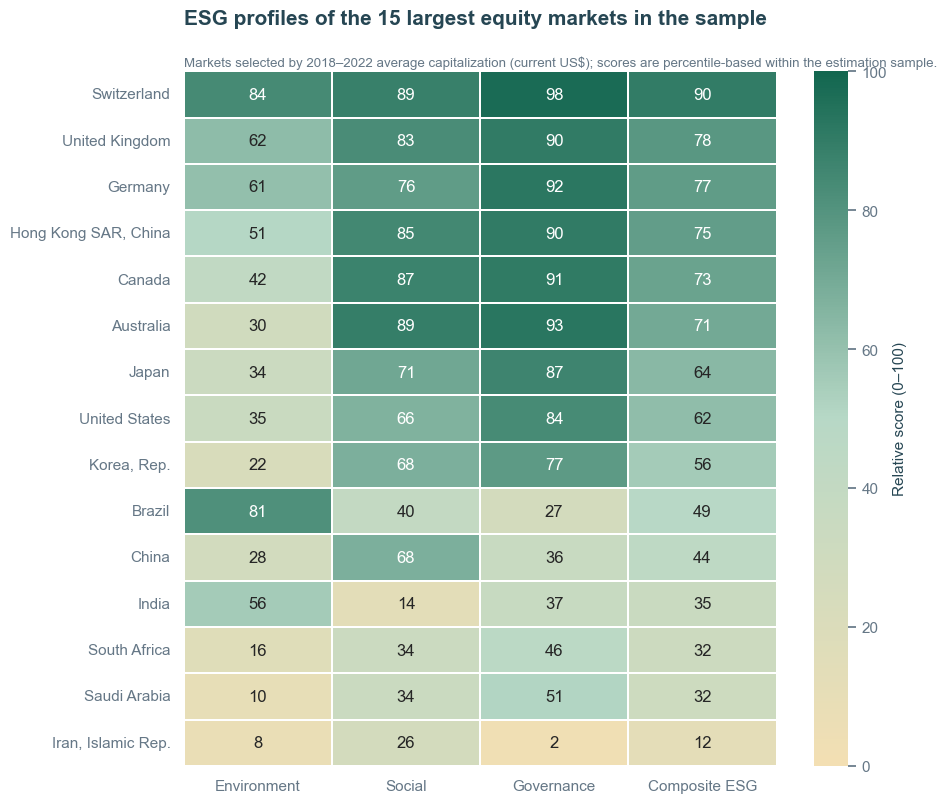

In [7]:
figure_3 = graph.plot_large_market_heatmap(df_clean, n_markets=15)
plt.show()

**Interpretation.** Among the 15 largest observed markets, Switzerland has the strongest composite profile (about 90). The United States is much stronger on governance (about 84) than environment (about 35), while Brazil shows the opposite pattern (environment about 81; governance about 27). These contrasts are economically meaningful for portfolio construction: equal composite scores can represent very different sources of sustainability exposure and risk.

## 5. OLS analysis

All models use OLS with **HC3 heteroskedasticity-robust standard errors**.

- **Model 1:** composite ESG only.
- **Model 2:** composite ESG + log PPP GDP per capita + standardized trade openness + log population.
- **Model 3:** E, S, and G separately + the same controls.

The outcome is `log(1 + winsorized market capitalization / GDP)`. ESG and each pillar are standardized, so focal coefficients represent a one-standard-deviation difference. Stars in the compact table denote `*** p<0.01`, `** p<0.05`, and `* p<0.10`; robust standard errors are in parentheses.

In [8]:
models = model.run(df_clean)
regression_results = model.regression_table(models)

display(
    regression_results.style
    .set_properties(**{"white-space": "pre-wrap", "text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#12664F"), ("color", "white")]},
        {"selector": "td", "props": [("border-bottom", "1px solid #E8ECE9")]},
    ])
)

,(1) ESG only,(2) ESG + controls,(3) Pillars + controls
Composite ESG (1 SD),0.195 (0.141),0.084 (0.146),
Environmental pillar (1 SD),,,-0.269* (0.147)
Social pillar (1 SD),,,-0.131 (0.167)
Governance pillar (1 SD),,,0.662*** (0.210)
Log GDP per capita (PPP),,0.531*** (0.144),0.019 (0.206)
Trade openness (1 SD),,0.207* (0.126),0.185 (0.126)
Log population,,0.315*** (0.072),0.333*** (0.067)
Constant,3.653*** (0.126),-7.044*** (2.042),-2.174 (2.379)
Observations,70,70,70
R-squared,0.035,0.330,0.448


### Full preferred-model output

In [9]:
preferred = models["(3) Pillars + controls"]
print(preferred.summary())

                            OLS Regression Results                            
Dep. Variable:       log_market_depth   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     12.42
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           3.50e-09
Time:                        23:12:36   Log-Likelihood:                -81.367
No. Observations:                  70   AIC:                             176.7
Df Residuals:                      63   BIC:                             192.5
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.1744      2.379     -0.

### Model interpretation

- **H1 is not supported.** Composite ESG is positive in Model 1 (`β=0.195`, `p=0.165`) but becomes small and statistically insignificant after controls in Model 2 (`β=0.084`, robust `SE=0.146`, `p=0.566`). Its adjusted estimate corresponds to roughly 8.7% higher `1 + market depth` per standard deviation, but the confidence interval includes zero.
- **H2 is supported.** In Model 3, governance is positive and statistically significant (`β=0.662`, robust `SE=0.210`, `p=0.0017`; 95% CI `[0.250, 1.074]`). In multiplicative terms, one standard deviation higher governance is associated with about **94% higher `1 + market-cap/GDP`**, conditional on the included variables.
- Environment is negative at the 10% level (`β=-0.269`, `p=0.068`) and social is not significant (`β=-0.131`, `p=0.435`). These are conditional associations, not evidence that environmental or social performance reduces firm value. They may reflect development pathways, omitted institutions, sample selection, or how country-level proxies map imperfectly to investable issuers.
- Model 3 explains **44.8%** of cross-country variation (`adjusted R²=39.5%`, `N=70`).

### Figure 4 — Focal OLS coefficients

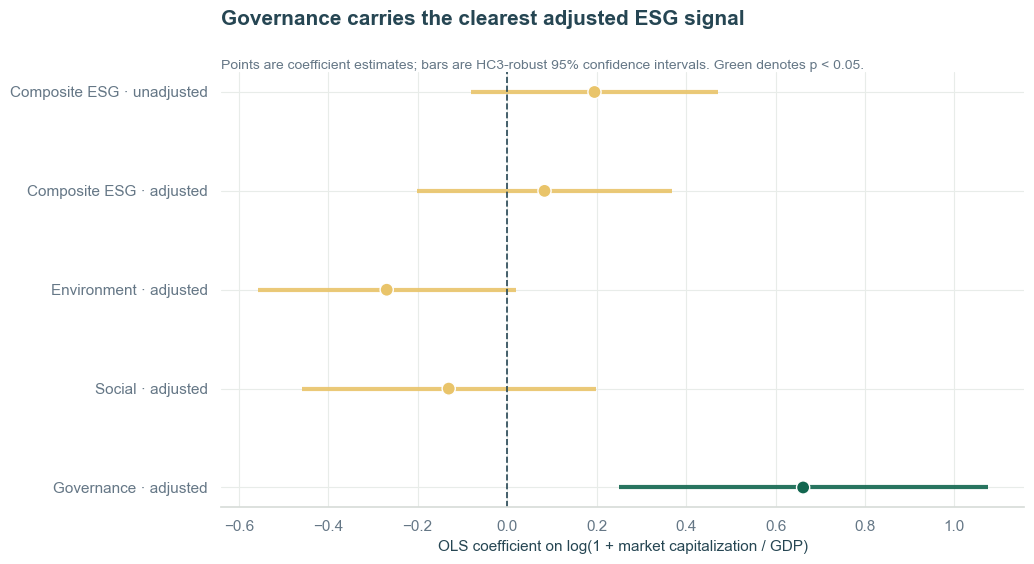

In [10]:
figure_4 = model.plot_key_coefficients(models)
plt.show()

**Interpretation.** Only the governance confidence interval lies clearly above zero. The composite interval crosses zero both before and after controls, showing why a headline ESG score should not be treated as a sufficient statistic. The environmental estimate is sensitive in sign and only marginally significant, so it should not be converted into a trading conclusion.

## 6. Diagnostics and influence sensitivity

In [11]:
vif, influential_cases = model.model_diagnostics(df_clean, preferred)
sensitivity, excluded_countries = model.influence_sensitivity(df_clean, preferred)

display(Markdown("**Variance inflation factors**"))
display(vif.style.format({"VIF": "{:.2f}"}))

display(Markdown("**Largest Cook's distances**"))
display(influential_cases.style.format({
    "cooks_distance": "{:.3f}", "threshold_4_over_n": "{:.3f}"
}))

comparison = pd.DataFrame(
    {
        "Baseline coefficient": preferred.params[["e_z", "s_z", "g_z"]],
        "Baseline p-value": preferred.pvalues[["e_z", "s_z", "g_z"]],
        "Excluding Cook's D > 4/n": sensitivity.params[["e_z", "s_z", "g_z"]],
        "Sensitivity p-value": sensitivity.pvalues[["e_z", "s_z", "g_z"]],
    },
    index=["e_z", "s_z", "g_z"],
).rename(index={"e_z": "Environment", "s_z": "Social", "g_z": "Governance"})

display(Markdown(f"**Influence sensitivity (excluded: {', '.join(excluded_countries)})**"))
display(comparison.style.format("{:.3f}"))

**Variance inflation factors**

,variable,VIF
0,Log GDP per capita (PPP),3.79
1,Governance pillar (1 SD),3.72
2,Social pillar (1 SD),2.91
3,Environmental pillar (1 SD),1.69
4,Trade openness (1 SD),1.44
5,Log population,1.38


**Largest Cook's distances**

indicator,country,cooks_distance,threshold_4_over_n
0,"Hong Kong SAR, China",0.136,0.057
1,"Iran, Islamic Rep.",0.129,0.057
2,Azerbaijan,0.076,0.057
3,Switzerland,0.057,0.057
4,Costa Rica,0.055,0.057


**Influence sensitivity (excluded: Hong Kong SAR, China, Azerbaijan, Iran, Islamic Rep.)**

,Baseline coefficient,Baseline p-value,Excluding Cook's D > 4/n,Sensitivity p-value
Environment,-0.269,0.068,-0.244,0.084
Social,-0.131,0.435,-0.096,0.526
Governance,0.662,0.002,0.654,0.000


**Diagnostic interpretation.** The maximum non-constant VIF is about **3.79**, below the common warning threshold of 5, so the pillar estimates are correlated but not dominated by severe multicollinearity. Hong Kong SAR, China; Azerbaijan; and Iran exceed the `4/n` Cook's-distance rule. Excluding them leaves the governance estimate almost unchanged (`β=0.654`, robust `p=0.0005`, `N=67`). The central governance result is therefore not driven by those three observations.

## 7. Limitations and sustainable-investing implications

### Limitations

1. **Association, not causation.** Reverse causality and omitted factors—legal origin, savings systems, market-access rules, or financial openness—may affect both governance and market depth.
2. **Country-to-issuer mapping.** Country fundamentals are not firm-level ESG performance. Multinationals operate across jurisdictions, and listing country may differ from operational exposure.
3. **Outcome choice.** Market capitalization / GDP measures market depth, not expected return, alpha, downside risk, or cost of capital.
4. **Score construction.** Percentiles and equal weights are transparent but normative. Different materiality weights could change ranks and coefficients.
5. **Measurement uncertainty.** WGI is perception-based and comes with uncertainty; small country differences should not be over-interpreted.
6. **Selection.** Market-capitalization coverage limits the analysis to 70 countries with observable equity markets, so results do not generalize to all economies.

### Implications

- The statistically clearest country-level signal is **governance**, consistent with investor attention to enforcement, regulatory quality, corruption risk, and stewardship conditions.
- A composite ESG score can dilute different signals; analysts should examine pillar and underlying-indicator exposures.
- The negative conditional E coefficient is a warning about proxy design and cross-country confounding—not a reason to ignore transition risk or environmental materiality.
- For security selection, this country screen should be combined with issuer materiality, valuation, transition plans, engagement evidence, and scenario analysis.

## 8. Conclusion and reproducibility

The answer to the first research question is nuanced: stronger composite ESG fundamentals show only a weak positive raw relationship with equity-market depth and no significant adjusted relationship. The second question produces a clearer result: **governance is the only pillar with a robust positive conditional association** in this sample. This supports decomposing ESG instead of treating a single score as an investment conclusion.

The workflow is reproducible and modular:

- `src/final_project/huang-shuo/basic/data.py` — official API acquisition and provenance
- `src/final_project/huang-shuo/basic/manipulate.py` — screening, averaging, scoring, and saved clean data
- `src/final_project/huang-shuo/basic/graph.py` — consistent publication-quality visuals
- `src/final_project/huang-shuo/basic/model.py` — OLS, robust tables, coefficient plot, and diagnostics
- `src/final_project/huang-shuo/basic/pipeline.py` — end-to-end runner

To reproduce everything from the repository root:

```bash
uv run python src/final_project/huang-shuo/basic/pipeline.py
```